In [56]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer


In [57]:
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))


import src.data_utils as du
importlib.reload(du)

<module 'src.data_utils' from '/vol/bitbucket/cl6523/nlp_cw/src/data_utils.py'>

In [58]:
DATA_DIR = PROJECT_ROOT / "data"
pcl_path = DATA_DIR / "dontpatronizeme.tsv"
df = du.load_pcl_tsv_to_df(pcl_path)
df = df.dropna(subset=['text', 'label'])
df = du.add_binary_label(df)

print(f"Dataset loaded successfully! Total rows: {len(df)}")

Dataset loaded successfully! Total rows: 10469


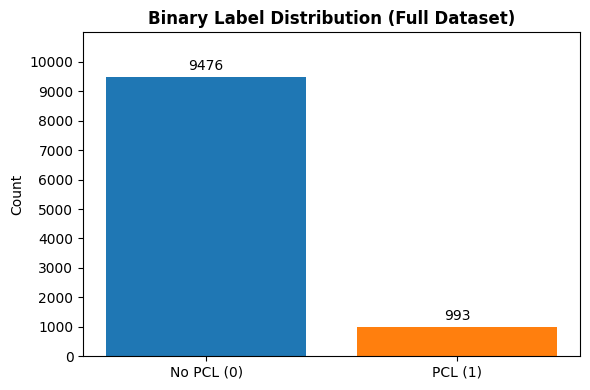

Class 0 (No PCL): 9476
Class 1 (PCL): 993
Imbalance Ratio: 1 positive example for every 9.54 negative examples.
Percentage of PCL: 9.49%


In [62]:
counts = df['binary_label'].value_counts().sort_index()
count_0 = counts[0]
count_1 = counts[1]

plt.figure(figsize=(6, 4))
bars = plt.bar(['No PCL (0)', 'PCL (1)'], [count_0, count_1], color=['tab:blue', 'tab:orange'])

plt.ylim(0, 11000)
plt.yticks(range(0, 10001, 1000))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 150, int(yval), ha='center', va='bottom')

plt.title("Binary Label Distribution (Full Dataset)", fontweight="bold")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Class 0 (No PCL): {count_0}")
print(f"Class 1 (PCL): {count_1}")
print(f"Imbalance Ratio: 1 positive example for every {count_0 / count_1:.2f} negative examples.")
print(f"Percentage of PCL: {(count_1 / (count_0 + count_1)) * 100:.2f}%")

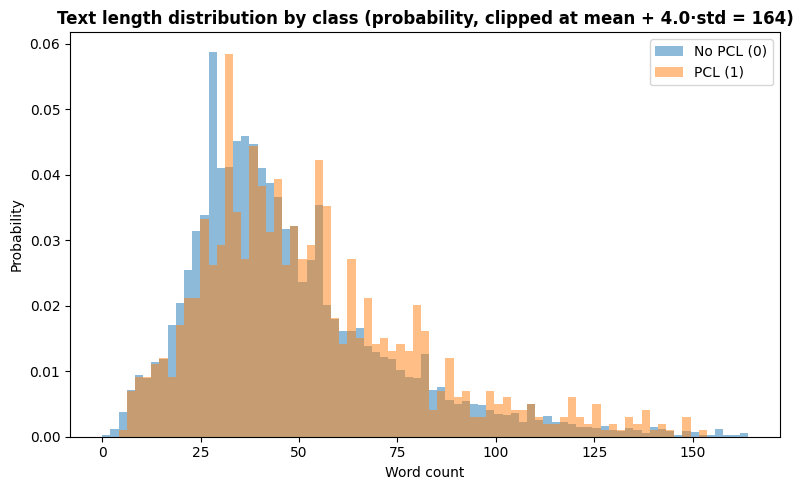

Class 0 (No PCL) - Mean: 47.88 words | Std: 28.62 words
Class 1 (PCL)    - Mean: 53.62 words | Std: 32.76 words


In [63]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

x0 = df.loc[df['binary_label'] == 0, 'word_count'].to_numpy()
x1 = df.loc[df['binary_label'] == 1, 'word_count'].to_numpy()

# Clip at 4 standard deviations above mean
all_lengths = df['word_count'].to_numpy()
clip_max = int(np.mean(all_lengths) + 4.0 * np.std(all_lengths))

bin_edges = np.linspace(0, clip_max, 80)

w0 = np.ones_like(x0, dtype=float) / len(x0)
w1 = np.ones_like(x1, dtype=float) / len(x1)

plt.figure(figsize=(8, 5))
plt.hist(x0, bins=bin_edges, weights=w0, alpha=0.5, label="No PCL (0)", color='tab:blue')
plt.hist(x1, bins=bin_edges, weights=w1, alpha=0.5, label="PCL (1)", color='tab:orange')

plt.xlabel("Word count")
plt.ylabel("Probability")
plt.title(f"Text length distribution by class (probability, clipped at mean + 4.0·std = {clip_max})", fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Class 0 (No PCL) - Mean: {np.mean(x0):.2f} words | Std: {np.std(x0):.2f} words")
print(f"Class 1 (PCL)    - Mean: {np.mean(x1):.2f} words | Std: {np.std(x1):.2f} words")

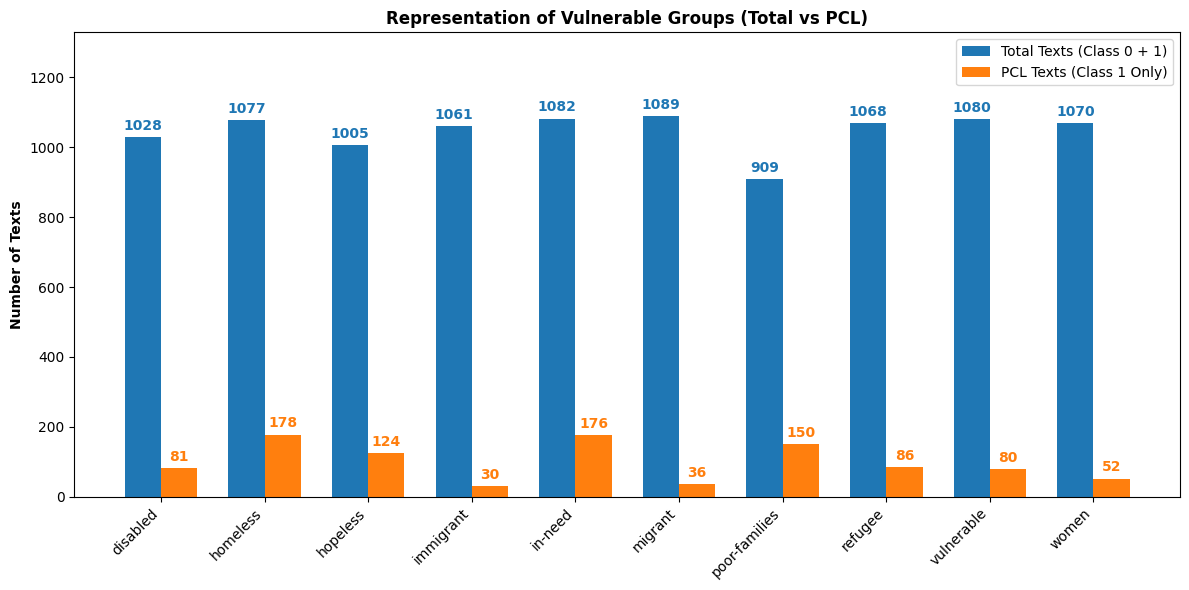

---------------------------------------------
PCL RATE (PERCENTAGE) PER VULNERABLE GROUP:
---------------------------------------------
Homeless        : 178 PCL / 1077 Total  (16.5%)
Poor-families   : 150 PCL /  909 Total  (16.5%)
In-need         : 176 PCL / 1082 Total  (16.3%)
Hopeless        : 124 PCL / 1005 Total  (12.3%)
Refugee         :  86 PCL / 1068 Total  (8.1%)
Disabled        :  81 PCL / 1028 Total  (7.9%)
Vulnerable      :  80 PCL / 1080 Total  (7.4%)
Women           :  52 PCL / 1070 Total  (4.9%)
Migrant         :  36 PCL / 1089 Total  (3.3%)
Immigrant       :  30 PCL / 1061 Total  (2.8%)


In [64]:
keyword_stats = df.groupby('keyword')['binary_label'].agg(['count', 'sum', 'mean']).reset_index()
keyword_stats = keyword_stats.rename(columns={'count': 'total_texts', 'sum': 'pcl_count', 'mean': 'pcl_rate'})
keyword_stats['pcl_rate'] = keyword_stats['pcl_rate'] * 100

keywords = keyword_stats['keyword'].tolist()
total_texts = keyword_stats['total_texts'].tolist()
pcl_counts = keyword_stats['pcl_count'].tolist()
pcl_rates = keyword_stats['pcl_rate'].tolist()

x = np.arange(len(keywords))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

rects1 = ax1.bar(x - width/2, total_texts, width, label='Total Texts (Class 0 + 1)', color='tab:blue')
rects2 = ax1.bar(x + width/2, pcl_counts, width, label='PCL Texts (Class 1 Only)', color='tab:orange')

ax1.set_ylabel('Number of Texts', fontweight='bold')
ax1.set_title('Representation of Vulnerable Groups (Total vs PCL)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(keywords, rotation=45, ha='right')

ax1.set_ylim(0, max(total_texts) * 1.22)

ax1.legend(loc='upper right', bbox_to_anchor=(1, 1), frameon=True)

for rect in rects1:
    height = rect.get_height()
    ax1.annotate(f'{int(height)}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', color='tab:blue', fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax1.annotate(f'{int(height)}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', color='tab:orange', fontweight='bold')

plt.tight_layout()
plt.show()


sorted_stats = keyword_stats.sort_values(by='pcl_rate', ascending=False)
print("-" * 45)
print("PCL RATE (PERCENTAGE) PER VULNERABLE GROUP:")
print("-" * 45)

for _, row in sorted_stats.iterrows():
    print(f"{row['keyword'].capitalize().ljust(15)} : "
          f"{int(row['pcl_count']):3d} PCL / "
          f"{int(row['total_texts']):4d} Total  "
          f"({row['pcl_rate']:.1f}%)")

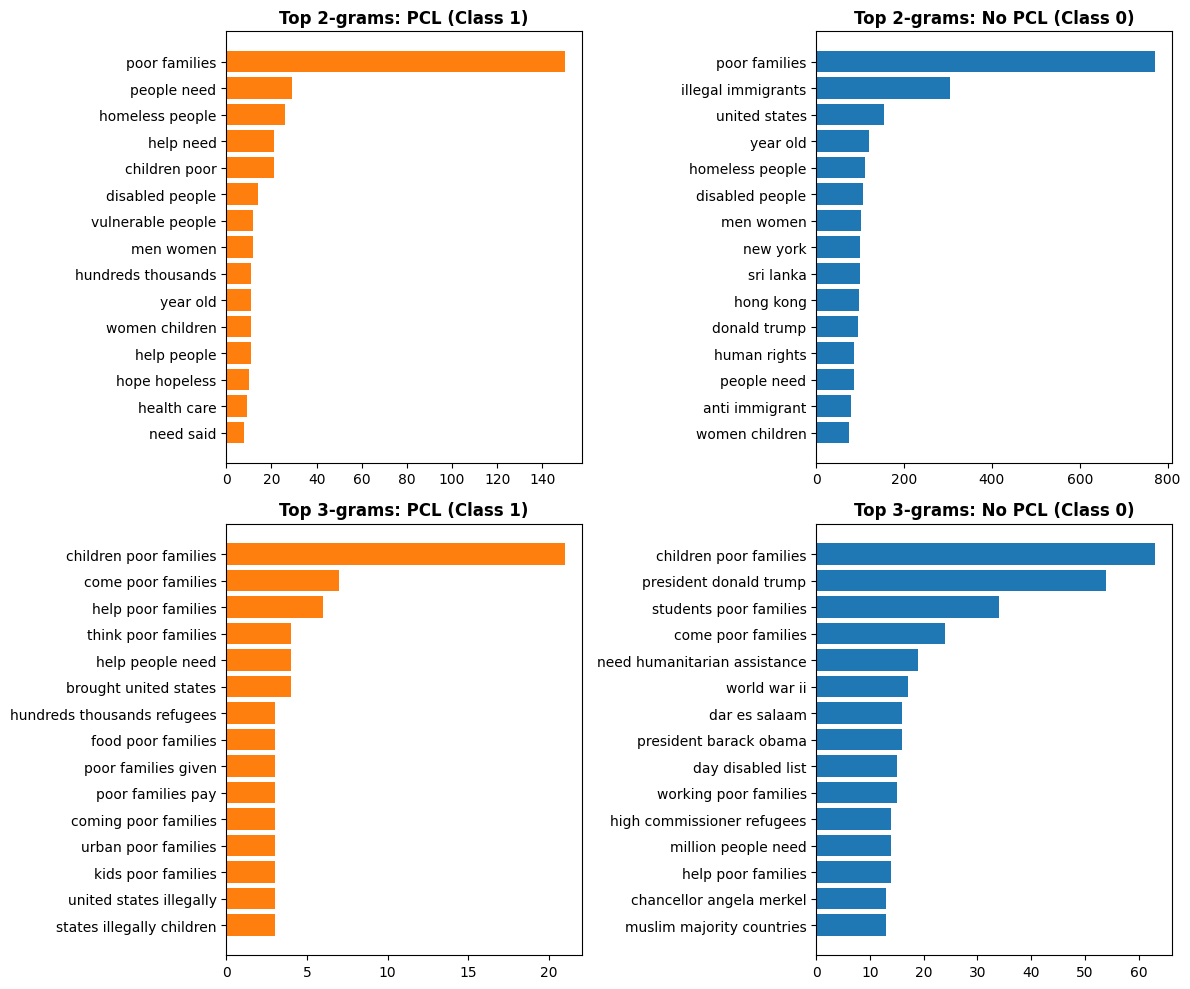

N-gram overlap

[ Bigram Overlap: 7/15 common phrases ]
Common phrases: men women, poor families, disabled people, year old, homeless people, women children, people need

[ Trigram Overlap: 3/15 common phrases ]
Common phrases: come poor families, help poor families, children poor families


In [67]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_k], columns=['ngram', 'count'])

pcl_texts = df[df['binary_label'] == 1]['text'].astype(str)
no_pcl_texts = df[df['binary_label'] == 0]['text'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
overlap_summary = []

for i, n in enumerate([2, 3]):
    df_pcl = get_top_ngrams(pcl_texts, n=n)
    df_no_pcl = get_top_ngrams(no_pcl_texts, n=n)

    overlap = set(df_pcl['ngram']).intersection(set(df_no_pcl['ngram']))
    overlap_summary.append((n, overlap))

    axes[i, 0].barh(df_pcl['ngram'], df_pcl['count'], color='tab:orange')
    axes[i, 0].set_title(f'Top {n}-grams: PCL (Class 1)', fontweight='bold')
    axes[i, 0].invert_yaxis()

    axes[i, 1].barh(df_no_pcl['ngram'], df_no_pcl['count'], color='tab:blue')
    axes[i, 1].set_title(f'Top {n}-grams: No PCL (Class 0)', fontweight='bold')
    axes[i, 1].invert_yaxis()

plt.tight_layout()
plt.show()


print("N-gram overlap")
for n, overlap in overlap_summary:
    label = "Bigram" if n == 2 else "Trigram"
    print(f"\n[ {label} Overlap: {len(overlap)}/15 common phrases ]")
    if len(overlap) > 0:
        print(f"Common phrases: {', '.join(list(overlap))}")
    else:
        print("No common phrases found in the top 15")